# **Hungary GP 2026**
## Results and Lap Analysis

In [1]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot
import Sliplib.battle_finder as battle

importlib.reload(slipclassify)
importlib.reload(grid_sum)
importlib.reload(battle)

<module 'Sliplib.battle_finder' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Hungary_GP/notebooks/../../Sliplib/battle_finder.py'>

In [2]:
# Load Session
session_Q = sl.load_gp(2025,"Hungarian Grand Prix","Q")
session_Q.load()

core           INFO 	Loading data for Hungarian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INF

### Result Inspection
Inspect Results of Qualifying Sessions

In [3]:
# Import Session Result
ses_res = session_Q.results
ses_res

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,1.0,,NaN,0 days 00:01:15.582000,0 days 00:01:15.455000,0 days 00:01:15.372000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,,NaN,0 days 00:01:15.211000,0 days 00:01:14.941000,0 days 00:01:15.398000,NaT,,NaN,NaN
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,3.0,,NaN,0 days 00:01:15.523000,0 days 00:01:14.890000,0 days 00:01:15.413000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,4.0,,NaN,0 days 00:01:15.627000,0 days 00:01:15.201000,0 days 00:01:15.425000,NaT,,NaN,NaN
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,5.0,,NaN,0 days 00:01:15.281000,0 days 00:01:15.395000,0 days 00:01:15.481000,NaT,,NaN,NaN
18,18,L STROLL,STR,stroll,Aston Martin,229971,aston_martin,Lance,Stroll,Lance Stroll,...,6.0,,NaN,0 days 00:01:15.673000,0 days 00:01:15.129000,0 days 00:01:15.498000,NaT,,NaN,NaN
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,7.0,,NaN,0 days 00:01:15.586000,0 days 00:01:15.687000,0 days 00:01:15.725000,NaT,,NaN,NaN
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,8.0,,NaN,0 days 00:01:15.736000,0 days 00:01:15.547000,0 days 00:01:15.728000,NaT,,NaN,NaN
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,9.0,,NaN,0 days 00:01:15.849000,0 days 00:01:15.630000,0 days 00:01:15.821000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,hadjar,Racing Bulls,6C98FF,rb,Isack,Hadjar,Isack Hadjar,...,10.0,,NaN,0 days 00:01:15.516000,0 days 00:01:15.469000,0 days 00:01:15.915000,NaT,,NaN,NaN


In [4]:
ses_res.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [5]:
# Display Clean Result
Q_result = slipclassify.clean_result_Quali(ses_res)
Q_result

,Abbreviation,TeamName,Position
16,LEC,Ferrari,1.0
81,PIA,McLaren,2.0
4,NOR,McLaren,3.0
63,RUS,Mercedes,4.0
14,ALO,Aston Martin,5.0
18,STR,Aston Martin,6.0
5,BOR,Kick Sauber,7.0
1,VER,Red Bull Racing,8.0
30,LAW,Racing Bulls,9.0
6,HAD,Racing Bulls,10.0


In [6]:
# Export Results of Quali
Q_result.to_csv("../data/Quali_Result.csv")

### Time Analysis

In [7]:
# Load lap data
Q_lap = session_Q.laps
Q_lap

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:20:34.562000,LEC,16,NaT,1.0,1.0,0 days 00:18:44.643000,NaT,NaT,0 days 00:00:35.750000,...,True,Ferrari,0 days 00:18:44.643000,2025-08-02 14:05:07.530,1,NaN,False,,False,False
1,0 days 00:21:50.778000,LEC,16,0 days 00:01:16.216000,2.0,1.0,NaT,NaT,0 days 00:00:27.753000,0 days 00:00:26.746000,...,True,Ferrari,0 days 00:20:34.562000,2025-08-02 14:06:57.449,1,NaN,False,,False,True
2,0 days 00:23:34.891000,LEC,16,0 days 00:01:44.113000,3.0,1.0,NaT,0 days 00:23:33.103000,0 days 00:00:38.500000,0 days 00:00:33.653000,...,True,Ferrari,0 days 00:21:50.778000,2025-08-02 14:08:13.665,1,NaN,False,,False,False
3,0 days 00:31:12.075000,LEC,16,NaT,4.0,2.0,0 days 00:29:18.622000,NaT,NaT,0 days 00:00:37.292000,...,True,Ferrari,0 days 00:23:34.891000,2025-08-02 14:09:57.778,1,NaN,False,,False,False
4,0 days 00:32:27.657000,LEC,16,0 days 00:01:15.582000,5.0,2.0,NaT,NaT,0 days 00:00:27.485000,0 days 00:00:26.723000,...,True,Ferrari,0 days 00:31:12.075000,2025-08-02 14:17:34.962,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,0 days 00:23:42.426000,ALB,23,0 days 00:01:16.448000,5.0,2.0,NaT,NaT,0 days 00:00:27.802000,0 days 00:00:26.976000,...,True,Williams,0 days 00:22:25.978000,2025-08-02 14:08:48.865,1,NaN,False,,False,True
260,0 days 00:25:12.896000,ALB,23,0 days 00:01:30.470000,6.0,2.0,NaT,0 days 00:25:11.165000,0 days 00:00:31.353000,0 days 00:00:32.597000,...,True,Williams,0 days 00:23:42.426000,2025-08-02 14:10:05.313,1,NaN,False,,False,False
261,0 days 00:30:20.970000,ALB,23,NaT,7.0,3.0,0 days 00:28:21.358000,NaT,NaT,0 days 00:00:34.013000,...,True,Williams,0 days 00:25:12.896000,2025-08-02 14:11:35.783,1,NaN,False,,False,False
262,0 days 00:31:37.193000,ALB,23,0 days 00:01:16.223000,8.0,3.0,NaT,NaT,0 days 00:00:27.725000,0 days 00:00:26.841000,...,True,Williams,0 days 00:30:20.970000,2025-08-02 14:16:43.857,1,NaN,False,,False,True


In [8]:
# Fastest Lap
fastest_lap = Q_lap.pick_fastest()
fastest_lap

Time                      0 days 00:45:33.218000
Driver                                       NOR
DriverNumber                                   4
LapTime                   0 days 00:01:14.890000
LapNumber                                    8.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:27.443000
Sector2Time               0 days 00:00:26.396000
Sector3Time               0 days 00:00:21.051000
Sector1SessionTime        0 days 00:44:45.771000
Sector2SessionTime        0 days 00:45:12.167000
Sector3SessionTime        0 days 00:45:33.218000
SpeedI1                                    279.0
SpeedI2                                    259.0
SpeedFL                                    262.0
SpeedST                                    310.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [9]:
# Make it pretty
pretty_fast = slipclassify.analyse_fastest(fastest_lap)
pretty_fast

,Name,Value
0,Driver,NOR
1,LapNumber,8.0
2,LapTime,1:14.890
3,Stint,3.0
4,Compound,SOFT


In [10]:
# Get the total lap, stint made by each driver
lap_stint_summary = slipclassify.get_lap_stint(Q_lap)
lap_stint_summary

,Driver,TotalLaps,TotalStint
0,LEC,18,6
1,PIA,18,6
2,NOR,18,6
3,RUS,15,5
4,ALO,15,5
5,STR,18,6
6,BOR,18,6
7,VER,18,6
8,LAW,18,6
9,HAD,15,5


In [11]:
# Extract the data
lap_stint_summary.to_csv("../data/Quali_Lap_stint.csv")

In [12]:
# Analyse Fresh Tyre Period
ft_period = slipclassify.get_fresh_tyre_period(Q_lap)
ft_period

,Driver,TyrePeriod
8,LAW,15
9,HAD,15
5,STR,15
4,ALO,15
3,RUS,12
2,NOR,12
1,PIA,12
0,LEC,12
7,VER,12
6,BOR,12


In [13]:
# Extract Data
ft_period.to_csv("../data/Fresh_Tyre_Period.csv",index=False)

## Race Result Analysis

In [14]:
# Load Race Session
R_session = sl.load_gp(2025,"Hungarian Grand Prix","R")
R_session.load()

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

In [15]:
# Load Result
R_result = R_session.results
R_result

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,1,3.0,NaT,NaT,NaT,0 days 01:35:21.231000,Finished,25.0,70.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:00.698000,Finished,18.0,70.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:21.916000,Finished,15.0,70.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,4,1.0,NaT,NaT,NaT,0 days 00:00:42.560000,Finished,12.0,70.0
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,5.0,5,5.0,NaT,NaT,NaT,0 days 00:00:59.040000,Finished,10.0,70.0
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,6.0,6,7.0,NaT,NaT,NaT,0 days 00:01:06.169000,Finished,8.0,70.0
18,18,L STROLL,STR,stroll,Aston Martin,229971,aston_martin,Lance,Stroll,Lance Stroll,...,7.0,7,6.0,NaT,NaT,NaT,0 days 00:01:08.174000,Finished,6.0,70.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,8.0,8,9.0,NaT,NaT,NaT,0 days 00:01:09.451000,Finished,4.0,70.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,9.0,9,8.0,NaT,NaT,NaT,0 days 00:01:12.645000,Finished,2.0,70.0
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,10.0,10,15.0,NaT,NaT,NaT,0 days 00:00:07.649000,Lapped,1.0,69.0


In [16]:
clear_race = slipclassify.clean_result_race(R_result)
clear_race

,Abbreviation,TeamName,ClassifiedPosition
4,NOR,McLaren,1
81,PIA,McLaren,2
63,RUS,Mercedes,3
16,LEC,Ferrari,4
14,ALO,Aston Martin,5
5,BOR,Kick Sauber,6
18,STR,Aston Martin,7
30,LAW,Racing Bulls,8
1,VER,Red Bull Racing,9
12,ANT,Mercedes,10


In [17]:
# Extract Data
clear_race.to_csv("../data/Race_Result.csv",index=False)

### Insights:
- Max got R
- Kimi got R
- Analysing the reason

In [18]:
messages = R_session.race_control_messages
messages

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2025-08-03 12:20:00,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
1,2025-08-03 12:30:00,Other,PIT EXIT CLOSED,None,None,None,NaN,None,1
2,2025-08-03 12:31:37,Flag,YELLOW IN TRACK SECTOR 3,None,YELLOW,Sector,3.0,None,1
3,2025-08-03 12:31:38,Other,DRS DISABLED IN ZONE 1,None,None,None,NaN,None,1
4,2025-08-03 12:31:39,Other,DRS DISABLED IN ZONE 2,None,None,None,NaN,None,1
...,...,...,...,...,...,...,...,...,...
91,2025-08-03 14:35:42,Flag,WAVED BLUE FLAG FOR CAR 27 (HUL) TIMED AT 16:3...,None,BLUE,Driver,NaN,27,68
92,2025-08-03 14:36:23,Flag,WAVED BLUE FLAG FOR CAR 55 (SAI) TIMED AT 16:3...,None,BLUE,Driver,NaN,55,69
93,2025-08-03 14:37:01,Other,FIA STEWARDS: 5 SECOND TIME PENALTY FOR CAR 16...,None,None,None,NaN,None,69
94,2025-08-03 14:38:27,Flag,CHEQUERED FLAG,None,CHEQUERED,Track,NaN,None,70


In [19]:
# Check Track Status
track_history = slipclassify.analyse_track_History(messages)
track_history

,Flags,Occurence
0,GREEN,2
1,None,0
2,YELLOW,2
3,CLEAR,2
4,BLUE,41
5,CHEQUERED,1


### Insights
- No Red Flag in the session
- So, no serious incidents
- But, minor incidents occured

In [20]:
# Position Gain Calculation of Drivers
ret_1 = grid_sum.calc_pos_gain(R_result)
ret_1

,Driver,PositionGain,Status
0,ANT,5.0,Finished
1,HUL,5.0,Finished
2,ALB,4.0,Finished
3,TSU,3.0,Finished
4,NOR,2.0,Finished
5,OCO,1.0,Finished
6,RUS,1.0,Finished
7,LAW,1.0,Finished
8,BOR,1.0,Finished
9,PIA,0.0,Finished


## Race Lap Analysis
From the above analysis, the Best Perfomance Drivers to examine are:
- Nico Hulkenberg
- Esteban Ocon
- Lando Norris
- Oscar Piastri
- Charles Leclerc
- Lewis Hamilton

In [21]:
R_Laps = R_session.laps
R_Laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:59:18.340000,NOR,4,0 days 00:01:30.120000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.396000,...,True,McLaren,0 days 00:57:47.946000,2025-08-03 13:03:06.040,1,5.0,False,,False,False
1,0 days 01:00:42.304000,NOR,4,0 days 00:01:23.964000,2.0,1.0,NaT,NaT,0 days 00:00:30.209000,0 days 00:00:30.346000,...,True,McLaren,0 days 00:59:18.340000,2025-08-03 13:04:36.434,1,5.0,False,,False,True
2,0 days 01:02:05.527000,NOR,4,0 days 00:01:23.223000,3.0,1.0,NaT,NaT,0 days 00:00:29.792000,0 days 00:00:30.097000,...,True,McLaren,0 days 01:00:42.304000,2025-08-03 13:06:00.398,1,4.0,False,,False,True
3,0 days 01:03:28.404000,NOR,4,0 days 00:01:22.877000,4.0,1.0,NaT,NaT,0 days 00:00:30.125000,0 days 00:00:29.665000,...,True,McLaren,0 days 01:02:05.527000,2025-08-03 13:07:23.621,1,4.0,False,,False,True
4,0 days 01:04:51.043000,NOR,4,0 days 00:01:22.639000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:29.672000,...,True,McLaren,0 days 01:03:28.404000,2025-08-03 13:08:46.498,1,4.0,False,,False,True


In [22]:
toppers,data= battle.find_top_battles(R_Laps,n=6)
data

[('HAD', 'BEA'),
 ('HUL', 'SAI'),
 ('ALB', 'OCO'),
 ('COL', 'GAS'),
 ('NOR', 'PIA'),
 ('LAW', 'VER')]

In [23]:
# Import Drivers
hul,oco,nor,pia,lec,ham = slipclassify.pick_athletes(R_Laps,["HUL","OCO","NOR","PIA","LEC","HAM"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
210,0 days 00:59:15.614000,LEC,16,0 days 00:01:27.394000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:29.783000,...,True,Ferrari,0 days 00:57:47.946000,2025-08-03 13:03:06.040,1,1.0,False,,False,False
211,0 days 01:00:38.443000,LEC,16,0 days 00:01:22.829000,2.0,1.0,NaT,NaT,0 days 00:00:30.160000,0 days 00:00:29.384000,...,True,Ferrari,0 days 00:59:15.614000,2025-08-03 13:04:33.708,1,1.0,False,,False,True
212,0 days 01:02:00.938000,LEC,16,0 days 00:01:22.495000,3.0,1.0,NaT,NaT,0 days 00:00:29.770000,0 days 00:00:29.427000,...,True,Ferrari,0 days 01:00:38.443000,2025-08-03 13:05:56.537,1,1.0,False,,False,True
213,0 days 01:03:23.216000,LEC,16,0 days 00:01:22.278000,4.0,1.0,NaT,NaT,0 days 00:00:29.755000,0 days 00:00:29.340000,...,True,Ferrari,0 days 01:02:00.938000,2025-08-03 13:07:19.032,1,1.0,False,,False,True
214,0 days 01:04:45.534000,LEC,16,0 days 00:01:22.318000,5.0,1.0,NaT,NaT,0 days 00:00:29.618000,0 days 00:00:29.300000,...,True,Ferrari,0 days 01:03:23.216000,2025-08-03 13:08:41.310,1,1.0,False,,False,True
215,0 days 01:06:07.891000,LEC,16,0 days 00:01:22.357000,6.0,1.0,NaT,NaT,0 days 00:00:29.666000,0 days 00:00:29.403000,...,True,Ferrari,0 days 01:04:45.534000,2025-08-03 13:10:03.628,1,1.0,False,,False,True
216,0 days 01:07:29.937000,LEC,16,0 days 00:01:22.046000,7.0,1.0,NaT,NaT,0 days 00:00:29.640000,0 days 00:00:29.277000,...,True,Ferrari,0 days 01:06:07.891000,2025-08-03 13:11:25.985,1,1.0,False,,False,True
217,0 days 01:08:51.677000,LEC,16,0 days 00:01:21.740000,8.0,1.0,NaT,NaT,0 days 00:00:29.561000,0 days 00:00:29.076000,...,True,Ferrari,0 days 01:07:29.937000,2025-08-03 13:12:48.031,1,1.0,False,,False,True
218,0 days 01:10:13.499000,LEC,16,0 days 00:01:21.822000,9.0,1.0,NaT,NaT,0 days 00:00:29.647000,0 days 00:00:29.130000,...,True,Ferrari,0 days 01:08:51.677000,2025-08-03 13:14:09.771,1,1.0,False,,False,True
219,0 days 01:11:35.443000,LEC,16,0 days 00:01:21.944000,10.0,1.0,NaT,NaT,0 days 00:00:29.741000,0 days 00:00:29.201000,...,True,Ferrari,0 days 01:10:13.499000,2025-08-03 13:15:31.593,1,1.0,False,,False,True


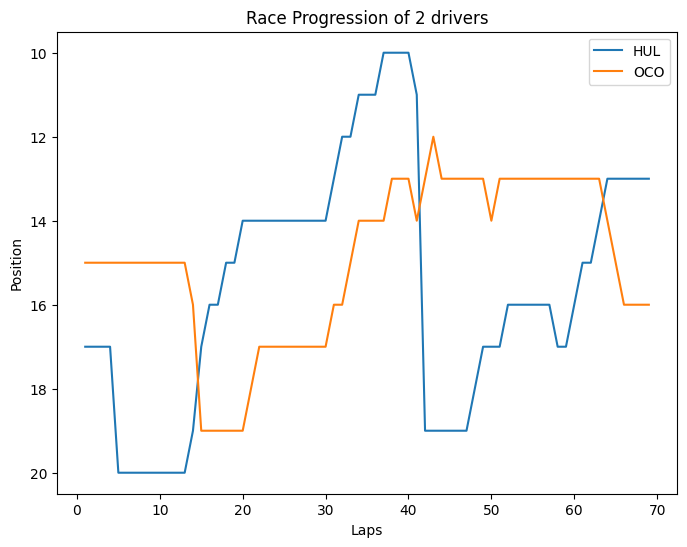

In [24]:
# Plot showing the 2 Contenders
slplot.plot_race_progression([hul,oco])

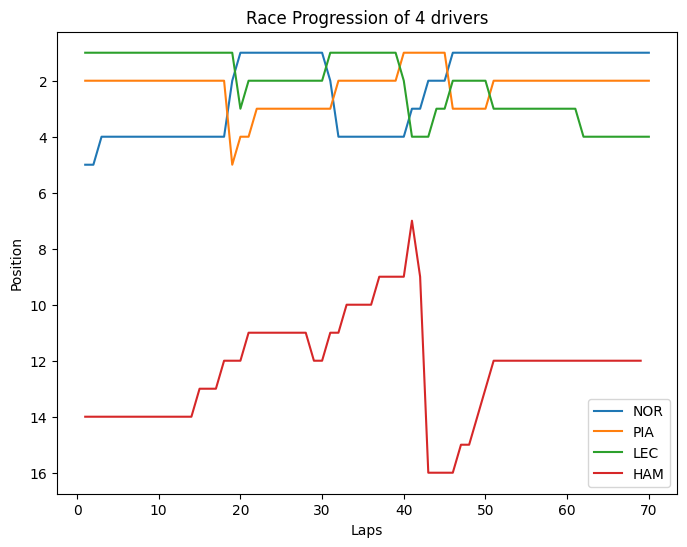

In [25]:
# Plots showing The Top grid
slplot.plot_race_progression([nor,pia,lec,ham])